In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve
import os
os.makedirs("figures", exist_ok=True)

In [2]:
MODEL_PATH = "models/binary_outcome_model.joblib"

bundle = joblib.load(MODEL_PATH)

pipe      = bundle["pipeline"]
sec_cols  = bundle["sec_cols"]
threshold = bundle["decision_threshold"]

print("Threshold:", threshold)

Threshold: 0.6799999999999999


In [3]:
TEST_PATH = "scraped_it_cases/test.csv"

df = pd.read_csv(TEST_PATH)

y_str = df["who_won"].astype(str)
y_true_bin = (y_str == "PETITIONER").astype(int)

In [4]:
def best_text_column(df_):
    if "text" in df_.columns and df_["text"].notna().any():
        return df_["text"].fillna("")
    if "combined_text" in df_.columns:
        return df_["combined_text"].fillna("")
    if {"title", "operative_snippet"}.issubset(df_.columns):
        return (df_["title"].fillna("") + " " + df_["operative_snippet"].fillna(""))
    return df.fillna("").astype(str).agg(" ".join, axis=1)

X = pd.DataFrame(index=df.index)
X["text"] = best_text_column(df)

for c in sec_cols:
    X[c] = df[c] if c in df.columns else 0

In [5]:
proba_pet = pipe.predict_proba(X)[:, 1]
pred_lab  = np.where(proba_pet >= threshold, "PETITIONER", "RESPONDENT")

y_pred_bin = (pred_lab == "PETITIONER").astype(int)

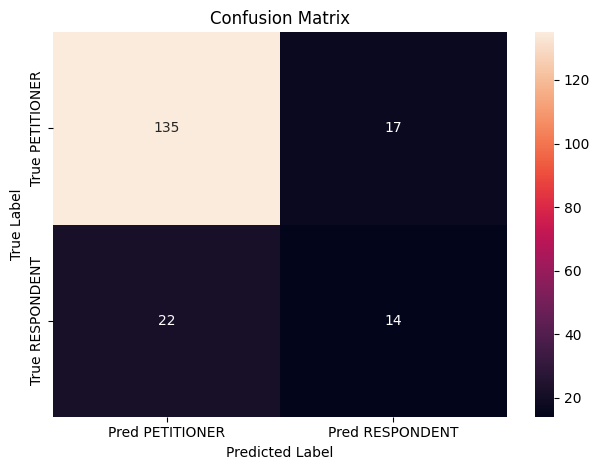

In [11]:
cm = confusion_matrix(y_str, pred_lab, labels=["PETITIONER", "RESPONDENT"])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Pred PETITIONER", "Pred RESPONDENT"],
            yticklabels=["True PETITIONER", "True RESPONDENT"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

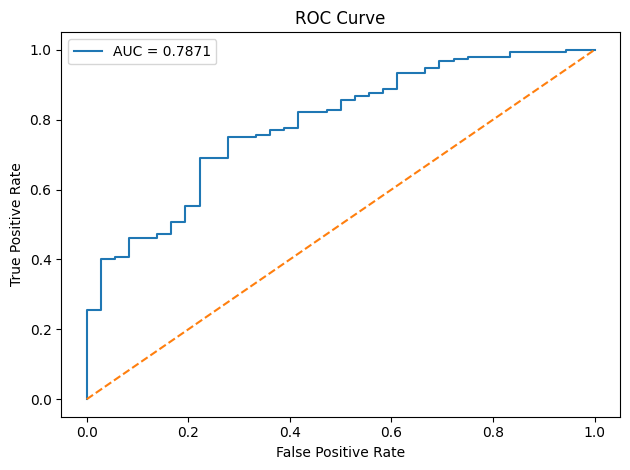

In [12]:
fpr, tpr, _ = roc_curve(y_true_bin, proba_pet)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true_bin, proba_pet):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=300)
plt.show()

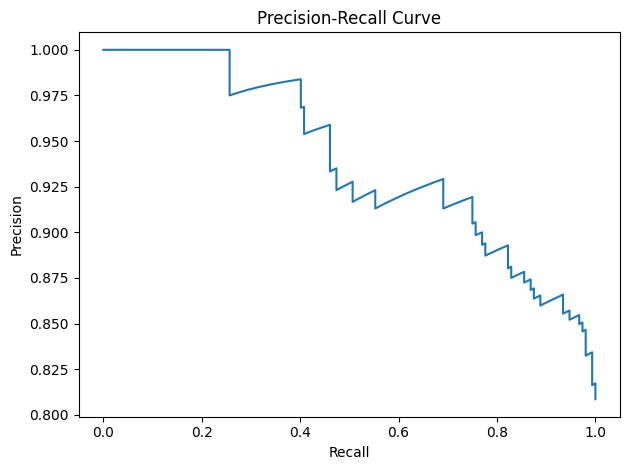

In [13]:
precision_vals, recall_vals, _ = precision_recall_curve(y_true_bin, proba_pet)

plt.figure()
plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("figures/precision_recall_curve.png", dpi=300)
plt.show()

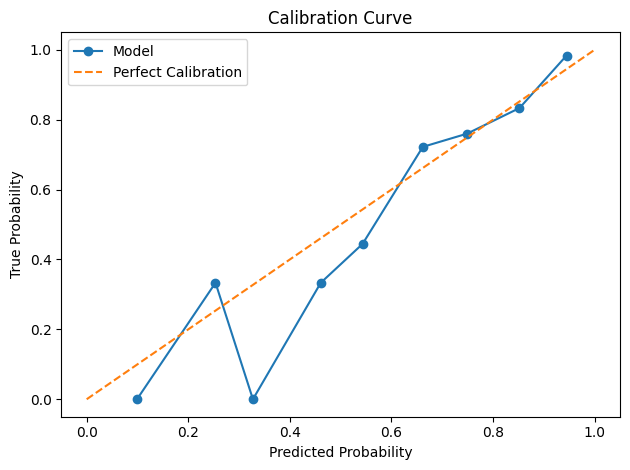

In [14]:
prob_true, prob_pred = calibration_curve(y_true_bin, proba_pet, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()

plt.tight_layout()
plt.savefig("figures/calibration_curve.png", dpi=300)
plt.show()

c:\Legal AI Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


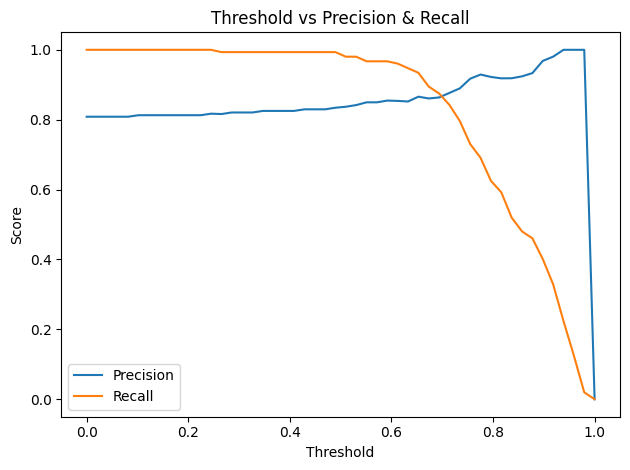

In [16]:
thresholds = np.linspace(0, 1, 50)
prec_list = []
rec_list = []

for t in thresholds:
    preds = (proba_pet >= t).astype(int)
    prec_list.append(precision_score(y_true_bin, preds))
    rec_list.append(recall_score(y_true_bin, preds))

plt.figure()
plt.plot(thresholds, prec_list, label="Precision")
plt.plot(thresholds, rec_list, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision & Recall")
plt.legend()

plt.tight_layout()
plt.savefig("figures/threshold_analysis.png", dpi=300)
plt.show()

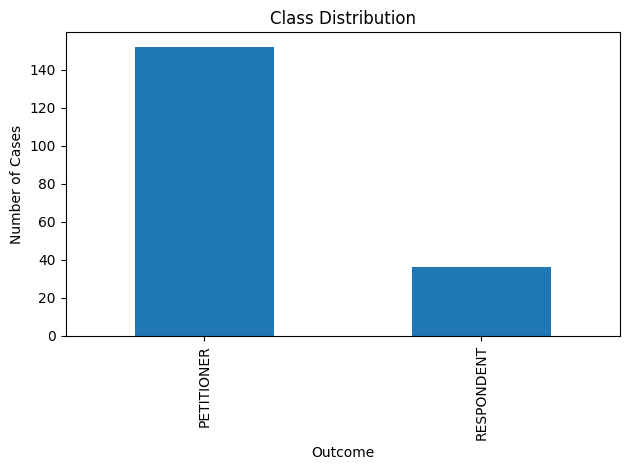

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("scraped_it_cases/test.csv")  # or your full dataset

counts = df["who_won"].value_counts()

plt.figure()
counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=300)
plt.show()